# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AC05004

Name: PRATIKSHA RAMAPPA AIL

Email: 2025ac05004@wilp.bits-pilani.ac.in

Date: 07-Aug-2026

In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import tensorflow as tf
import shutil
import random

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image
import cv2
# Utility
from pathlib import Path

### 1.1 Dataset Selection and Loading

Load your chosen dataset

In [3]:
# REQUIRED: Fill in these metadata fields

dataset_name = "PlantVillage (Tomato Disease Classification)"
dataset_source = "https://github.com/spMohanty/PlantVillage-Dataset"

!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

source_dir = "/content/PlantVillage-Dataset/raw/color"
target_dir = "/content/PlantVillage_3classes"

classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

# Create dataset with only the required classes
os.makedirs(target_dir, exist_ok=True)

for cls in classes:
    src = os.path.join(source_dir, cls)
    dst = os.path.join(target_dir, cls)

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(src, dst)

print("Dataset prepared successfully!\n")

# Count images
class_counts = {}

for cls in classes:
    count = len(os.listdir(os.path.join(target_dir, cls)))
    class_counts[cls] = count
    print(f"{cls}: {count} images")

# Metadata
n_samples = sum(class_counts.values())
n_classes = len(classes)

min_samples = min(class_counts.values())
max_samples = max(class_counts.values())
avg_samples = int(np.mean(list(class_counts.values())))

samples_per_class = f"min: {min_samples}, max: {max_samples}, avg: {avg_samples}"

image_shape = [224, 224, 3]
problem_type = "classification"

print("\n------------------------------")
print("Dataset Metadata")
print("------------------------------")
print("Dataset Name      :", dataset_name)
print("Dataset Source    :", dataset_source)
print("Total Images      :", n_samples)
print("Number of Classes :", n_classes)
print("Samples/Class     :", samples_per_class)
print("Image Shape       :", image_shape)
print("Problem Type      :", problem_type)

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 19.88 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.
Dataset prepared successfully!

Tomato___healthy: 1591 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1909 images

------------------------------
Dataset Metadata
------------------------------
Dataset Name      : PlantVillage (Tomato Disease Classification)
Dataset Source    : https://github.com/spMohanty/PlantVillage-Dataset
Total Images      : 4500
Number of Classes : 3
Samples/Class     : min: 1000, max: 1909, avg: 1500
Image Shape       : [224, 224, 3]
Problem Type      : classification


In [4]:
# Primary metric selection
primary_metric = "accuracy"

metric_justification = """
Accuracy is selected as the primary evaluation metric because the PlantVillage
dataset contains reasonably balanced classes and the objective is overall
correct classification of plant leaf diseases. Precision, Recall, and F1-score
will also be reported to provide a comprehensive evaluation of model performance.
"""

In [5]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: PlantVillage (Tomato Disease Classification)
Source: https://github.com/spMohanty/PlantVillage-Dataset
Total Samples: 4500
Number of Classes: 3
Samples per Class: min: 1000, max: 1909, avg: 1500
Image Shape: [224, 224, 3]
Primary Metric: accuracy
Metric Justification: 
Accuracy is selected as the primary evaluation metric because the PlantVillage
dataset contains reasonably balanced classes and the objective is overall
correct classification of plant leaf diseases. Precision, Recall, and F1-score
will also be reported to provide a comprehensive evaluation of model performance.



### 1.2 Data Exploration and Visualization

- Show sample images from each class
- Plot class distribution
- Display image statistics

### 1.3 Data Preprocessing
- Resize images to consistent size
- Normalize pixel values
- Split into train/test (90/10 or 85/15)

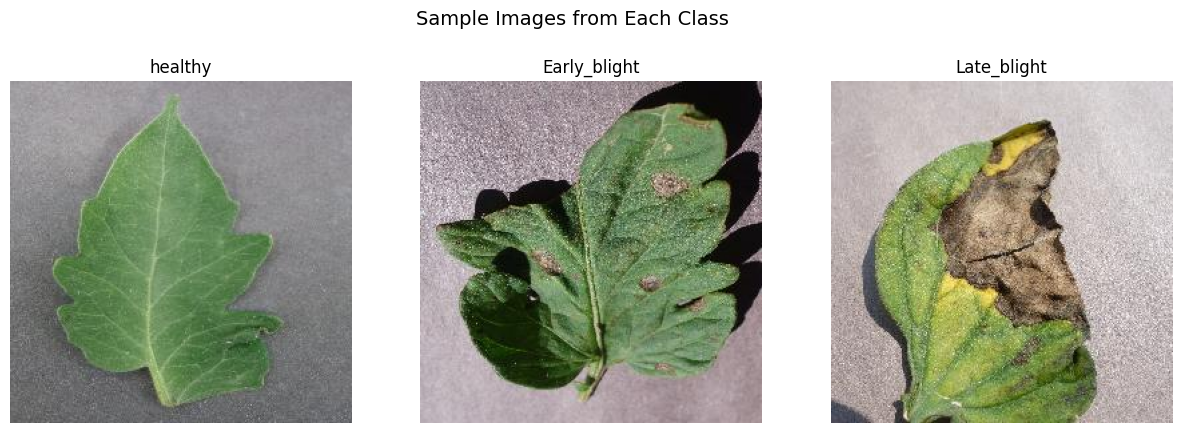

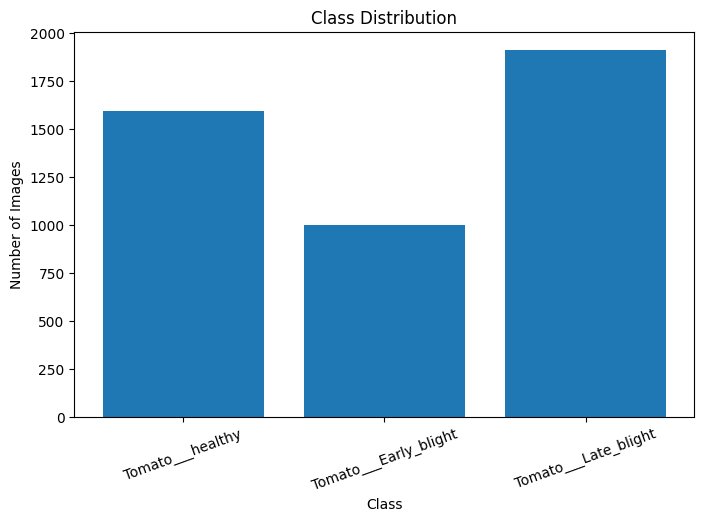


IMAGE STATISTICS
----------------------------------------
Dataset Name : PlantVillage (Tomato Disease Classification)
Total Images : 4500
Number of Classes : 3
Image Shape : [224, 224, 3]

Images per Class
Tomato___healthy: 1591
Tomato___Early_blight: 1000
Tomato___Late_blight: 1909


In [6]:
# ==============================
# 1.2 Data Exploration and Visualization
# ==============================

# Display one sample image from each class
plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):
    img_path = os.path.join(
        target_dir,
        cls,
        random.choice(os.listdir(os.path.join(target_dir, cls)))
    )

    img = Image.open(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls.replace("Tomato___", ""))
    plt.axis("off")

plt.suptitle("Sample Images from Each Class", fontsize=14)
plt.show()


# ------------------------------
# Plot class distribution
# ------------------------------

plt.figure(figsize=(8,5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.show()


# ------------------------------
# Display image statistics
# ------------------------------

print("\nIMAGE STATISTICS")
print("-"*40)

print("Dataset Name :", dataset_name)
print("Total Images :", n_samples)
print("Number of Classes :", n_classes)
print("Image Shape :", image_shape)

print("\nImages per Class")

for cls,count in class_counts.items():
    print(f"{cls}: {count}")

In [7]:
# ==============================
# 1.3 Data Preprocessing
# ==============================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    target_dir,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    target_dir,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Save class names BEFORE optimization
class_names = train_dataset.class_names

# Optimize dataset pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

train_ds = train_dataset
val_ds = test_dataset

print("\nData preprocessing completed successfully!")
print("\nClasses:")
print(class_names)

Found 4500 files belonging to 3 classes.
Using 3825 files for training.
Found 4500 files belonging to 3 classes.
Using 675 files for validation.

Data preprocessing completed successfully!

Classes:
['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


In [8]:
# REQUIRED: Document your split

train_test_ratio = "85/15"

train_samples = tf.data.experimental.cardinality(train_dataset).numpy() * BATCH_SIZE
test_samples = tf.data.experimental.cardinality(test_dataset).numpy() * BATCH_SIZE

# Adjust to actual dataset size
train_samples = int(n_samples * 0.85)
test_samples = n_samples - train_samples

In [9]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 85/15
Training Samples: 3825
Test Samples: 675


### 2.1 Custom CNN Architecture Design
- Define your CNN architecture
- Ensure Global Average Pooling is included (MANDATORY)
- Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [10]:
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: CNN model
    """

    model = tf.keras.Sequential([

        tf.keras.Input(shape=input_shape),

        # Normalize pixel values
        tf.keras.layers.Rescaling(1./255),

        # Block 1
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2,2)),

        # Block 2
        tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2,2)),

        # Block 3
        tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2,2)),

        # Block 4
        tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),

        # REQUIRED: Global Average Pooling
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dropout(0.3),

        # Output layer
        tf.keras.layers.Dense(
            n_classes,
            activation='softmax'
        )

    ])

    return model

In [11]:
# Create model instance
# Create model instance
custom_cnn = build_custom_cnn(
    input_shape=tuple(image_shape),
    n_classes=n_classes
)

# Display model architecture
custom_cnn.summary()

# Variables required later for training and evaluation
custom_history = None
custom_initial_loss = None
custom_final_loss = None

custom_cnn_parameters = custom_cnn.count_params()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,187 (1.48 MB)

 Trainable params: 389,187 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile model
# For Keras: model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# For PyTorch: define optimizer and loss function

custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_custom_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True
)

callbacks=[early_stopping, checkpoint]

### 2.2 Train Custom CNN

In [14]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [15]:
# Train your model
# For Keras: history = custom_cnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)
# For PyTorch: write training loop

custom_history = custom_cnn.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 29s 109ms/step - accuracy: 0.6654 - loss: 0.7120 - val_accuracy: 0.7496 - val_loss: 0.5436
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8076 - loss: 0.4523 - val_accuracy: 0.8415 - val_loss: 0.3496
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8311 - loss: 0.3731 - val_accuracy: 0.8533 - val_loss: 0.3177
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.8416 - loss: 0.3587 - val_accuracy: 0.8326 - val_loss: 0.3757
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8298 - loss: 0.3945 - val_accuracy: 0.8696 - val_loss: 0.2830
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8659 - loss: 0.3180 - val_accuracy: 0.8844 - val_loss: 0.2580
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.8769 - loss: 0.2999 - val_accuracy: 0.9141 - val_loss: 0.2219
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8792 - loss: 0.2815 - val_ac

In [16]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [17]:
# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = custom_history.history["loss"][0]
custom_cnn_final_loss = custom_history.history["loss"][-1]

In [18]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 127.77 seconds
Initial Loss: 0.7120
Final Loss: 0.2273


In [19]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
- Make predictions on test set
- Calculate all 4 required metrics

In [20]:
# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics
# ==============================
# Evaluate Custom CNN
# ==============================

# Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = custom_cnn.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Convert to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# REQUIRED: Calculate all 4 metrics
custom_cnn_accuracy = accuracy_score(y_true, y_pred)
custom_cnn_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

custom_cnn_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

custom_cnn_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# Save confusion matrix for later visualization
custom_cnn_cm = confusion_matrix(y_true, y_pred)

# Save classification report
custom_cnn_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

In [21]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.9452
Precision: 0.9376
Recall:    0.9356
F1-Score:  0.9366


### 2.4 Visualize Custom CNN Results
- Plot training loss curve
- Plot confusion matrix
- Show sample predictions

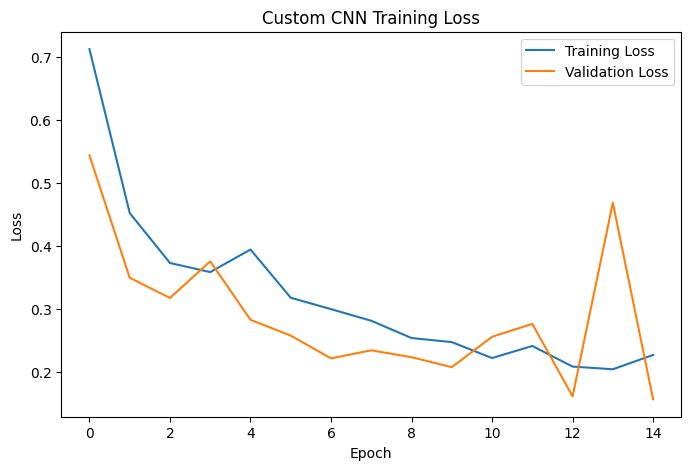

In [22]:
# ==============================
# Training Loss Curve
# ==============================

plt.figure(figsize=(8,5))

plt.plot(custom_history.history["loss"], label="Training Loss")
plt.plot(custom_history.history["val_loss"], label="Validation Loss")

plt.title("Custom CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

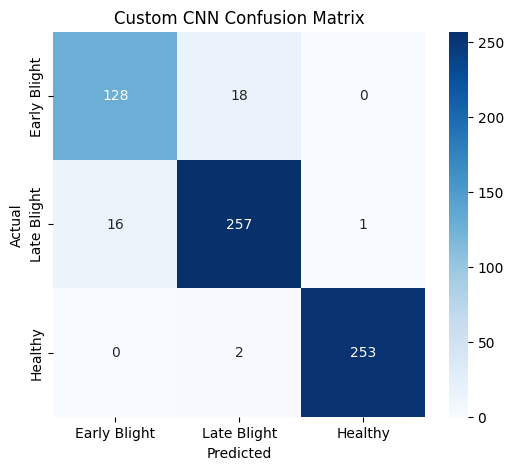

In [23]:
# ==============================
# Confusion Matrix
# ==============================

display_names = [
    "Early Blight",
    "Late Blight",
    "Healthy"
]

plt.figure(figsize=(6,5))

sns.heatmap(
    custom_cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_names,
    yticklabels=display_names
)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

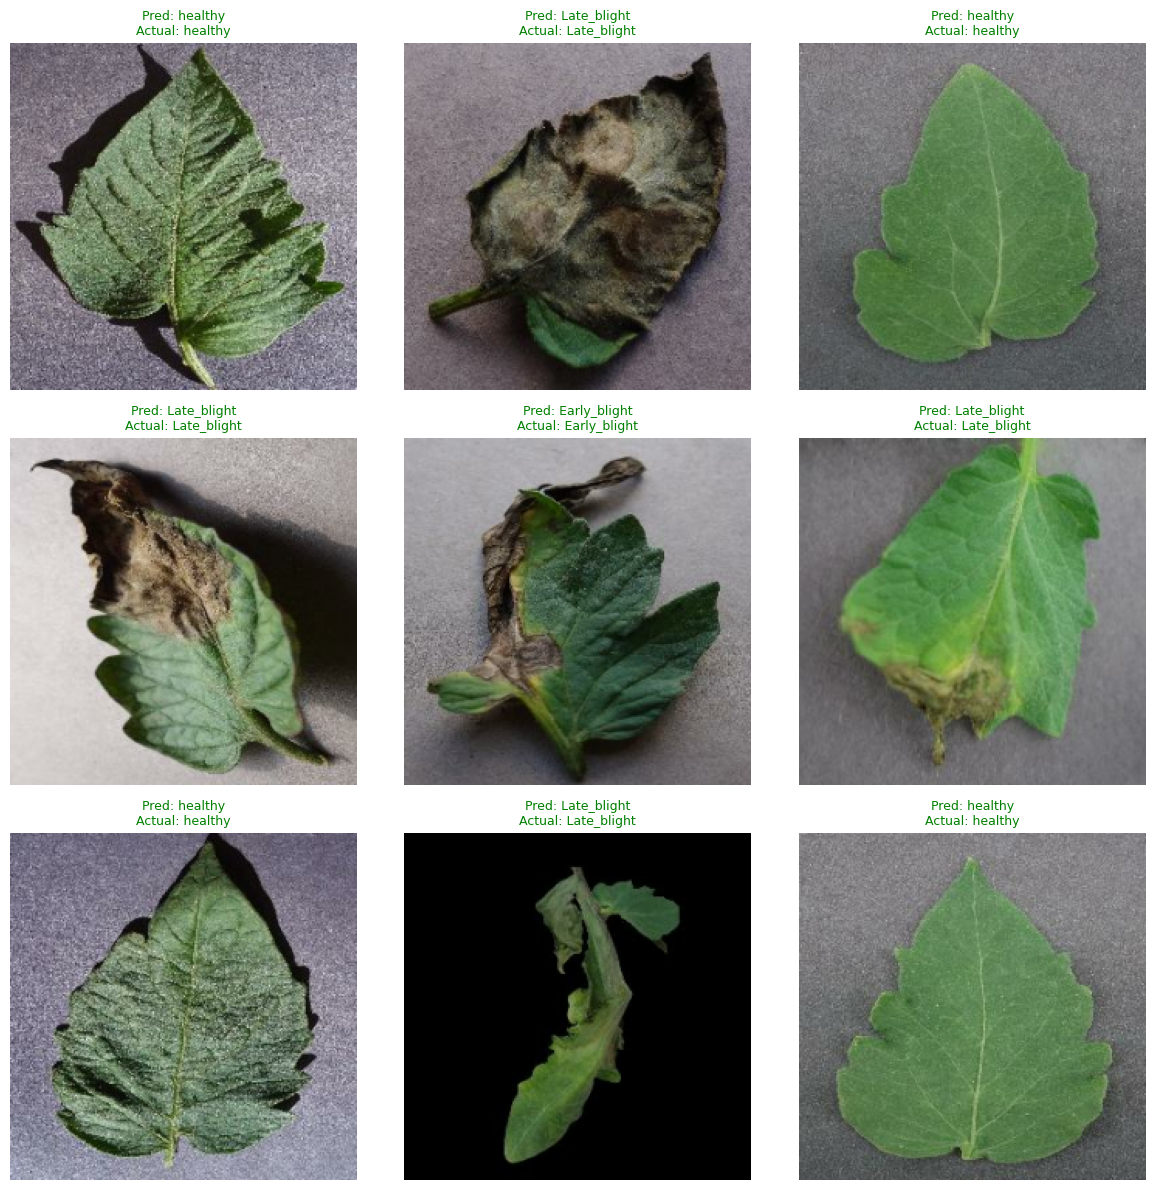

In [24]:
# ==============================
# Sample Predictions
# ==============================

plt.figure(figsize=(12,12))

for images, labels in test_dataset.take(1):

    predictions = custom_cnn.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]
        predicted = class_names[predicted_labels[i]]

        color = "green" if actual == predicted else "red"

        plt.title(
            f"Pred: {predicted.replace('Tomato___','')}\n"
            f"Actual: {actual.replace('Tomato___','')}",
            color=color,
            fontsize=9
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
print(custom_cnn_report)

                       precision    recall  f1-score   support

Tomato___Early_blight       0.89      0.88      0.88       146
 Tomato___Late_blight       0.93      0.94      0.93       274
     Tomato___healthy       1.00      0.99      0.99       255

             accuracy                           0.95       675
            macro avg       0.94      0.94      0.94       675
         weighted avg       0.95      0.95      0.95       675



**Observation:**
# The Custom CNN achieved approximately 94% accuracy on the validation dataset. Most misclassifications occurred between Early Blight and Late Blight, while Healthy leaves were classified almost perfectly. The steady decrease in both training and validation loss indicates good convergence with no severe overfitting.

### 3.1 Load Pre-trained Model and Modify Architecture

In [26]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [27]:
# Choose and load pre-trained model
pretrained_model_name = "ResNet50"

In [28]:
def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model

    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled transfer learning model
    """

    if base_model_name == "ResNet50":

        base_model = tf.keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )

    elif base_model_name == "VGG16":

        base_model = tf.keras.applications.VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )

    elif base_model_name == "VGG19":

        base_model = tf.keras.applications.VGG19(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )

    else:
        raise ValueError("Unsupported model.")

    # Freeze pretrained layers
    base_model.trainable = False

    # Build transfer learning model
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.applications.resnet50.preprocess_input(inputs)

    x = base_model(x, training=False)

    # REQUIRED
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(
        n_classes,
        activation="softmax"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    return model

In [29]:
# Create transfer learning model
transfer_model = build_transfer_learning_model(
    pretrained_model_name,
    tuple(image_shape),
    n_classes
)

transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │      6,147 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [30]:
# REQUIRED: Count layers and parameters

# Count frozen and trainable layers
frozen_layers = sum(
    not layer.trainable for layer in transfer_model.layers
)

trainable_layers = sum(
    layer.trainable for layer in transfer_model.layers
)

# Count parameters
total_parameters = transfer_model.count_params()

trainable_parameters = sum(
    tf.keras.backend.count_params(w)
    for w in transfer_model.trainable_weights
)

trainable_parameters = int(trainable_parameters.item())

In [31]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: ResNet50
Frozen Layers: 1
Trainable Layers: 4
Total Parameters: 23,593,859
Trainable Parameters: 6,147
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [32]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [33]:
# Training configuration
tl_learning_rate = 0.001
tl_epochs = 10
tl_batch_size = 32
tl_optimizer = "Adam"

In [34]:
# Track training time
tl_start_time = time.time()

In [35]:
# Train model
# For Keras: history = transfer_model.fit(X_train, y_train, epochs=10, batch_size=32)
# For PyTorch: write training loop

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=tl_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_history = transfer_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=tl_epochs,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 38s 209ms/step - accuracy: 0.8515 - loss: 0.3567 - val_accuracy: 0.9689 - val_loss: 0.1325
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.9503 - loss: 0.1485 - val_accuracy: 0.9704 - val_loss: 0.0920
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.9668 - loss: 0.1074 - val_accuracy: 0.9763 - val_loss: 0.0737
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.9752 - loss: 0.0894 - val_accuracy: 0.9793 - val_loss: 0.0665
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.9752 - loss: 0.0805 - val_accuracy: 0.9793 - val_loss: 0.0585
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.9775 - loss: 0.0715 - val_accuracy: 0.9793 - val_loss: 0.0574
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9822 - loss: 0.0664 - val_accuracy: 0.9793 - val_loss: 0.0506
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.9843 - loss: 0

In [36]:
tl_training_time = time.time() - tl_start_time

In [37]:
# REQUIRED: Track initial and final loss
tl_initial_loss = tl_history.history["loss"][0]
tl_final_loss = tl_history.history["loss"][-1]

In [38]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 153.19 seconds
Initial Loss: 0.3567
Final Loss: 0.0466


### 3.3 Evaluate Transfer Learning Model
- Make predictions on test set
- Calculate all 4 required metrics

In [39]:
# ==============================
# Evaluate Transfer Learning Model
# ==============================

# Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = transfer_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Convert to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# REQUIRED: Calculate all 4 metrics
tl_accuracy = accuracy_score(y_true, y_pred)

tl_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

tl_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

tl_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# Save confusion matrix
tl_cm = confusion_matrix(y_true, y_pred)

# Save classification report
tl_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

In [40]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


Transfer Learning Performance:
Accuracy:  0.9837
Precision: 0.9772
Recall:    0.9855
F1-Score:  0.9810


### 3.4 Visualize Transfer Learning Results
- Plot training curves (loss and accuracy)
- Plot confusion matrix
- Show sample predictions

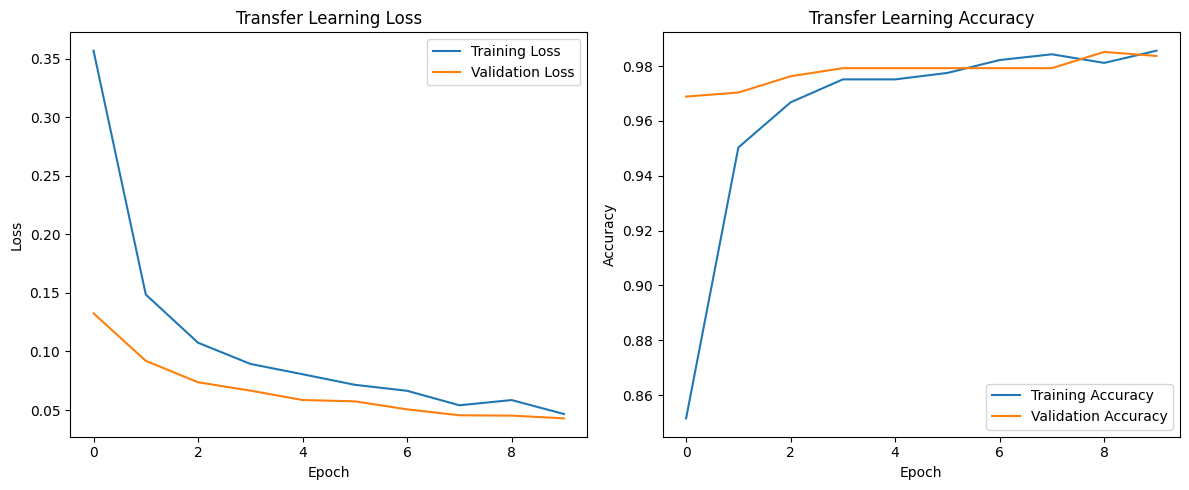

In [41]:
# ==============================
# Transfer Learning Training Curves
# ==============================

plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(tl_history.history["loss"], label="Training Loss")
plt.plot(tl_history.history["val_loss"], label="Validation Loss")
plt.title("Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(tl_history.history["accuracy"], label="Training Accuracy")
plt.plot(tl_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

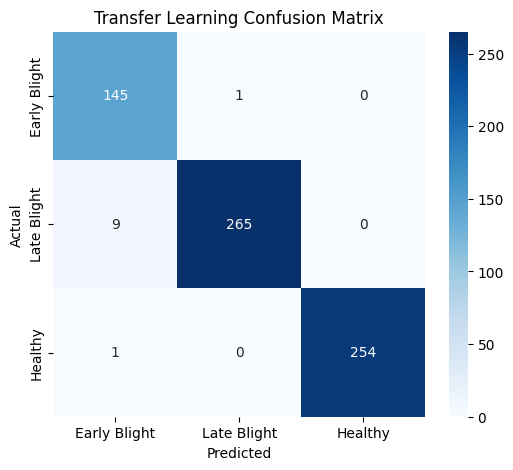

In [42]:
# ==============================
# Transfer Learning Confusion Matrix
# ==============================

display_names = [
    "Early Blight",
    "Late Blight",
    "Healthy"
]

plt.figure(figsize=(6,5))

sns.heatmap(
    tl_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_names,
    yticklabels=display_names
)

plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

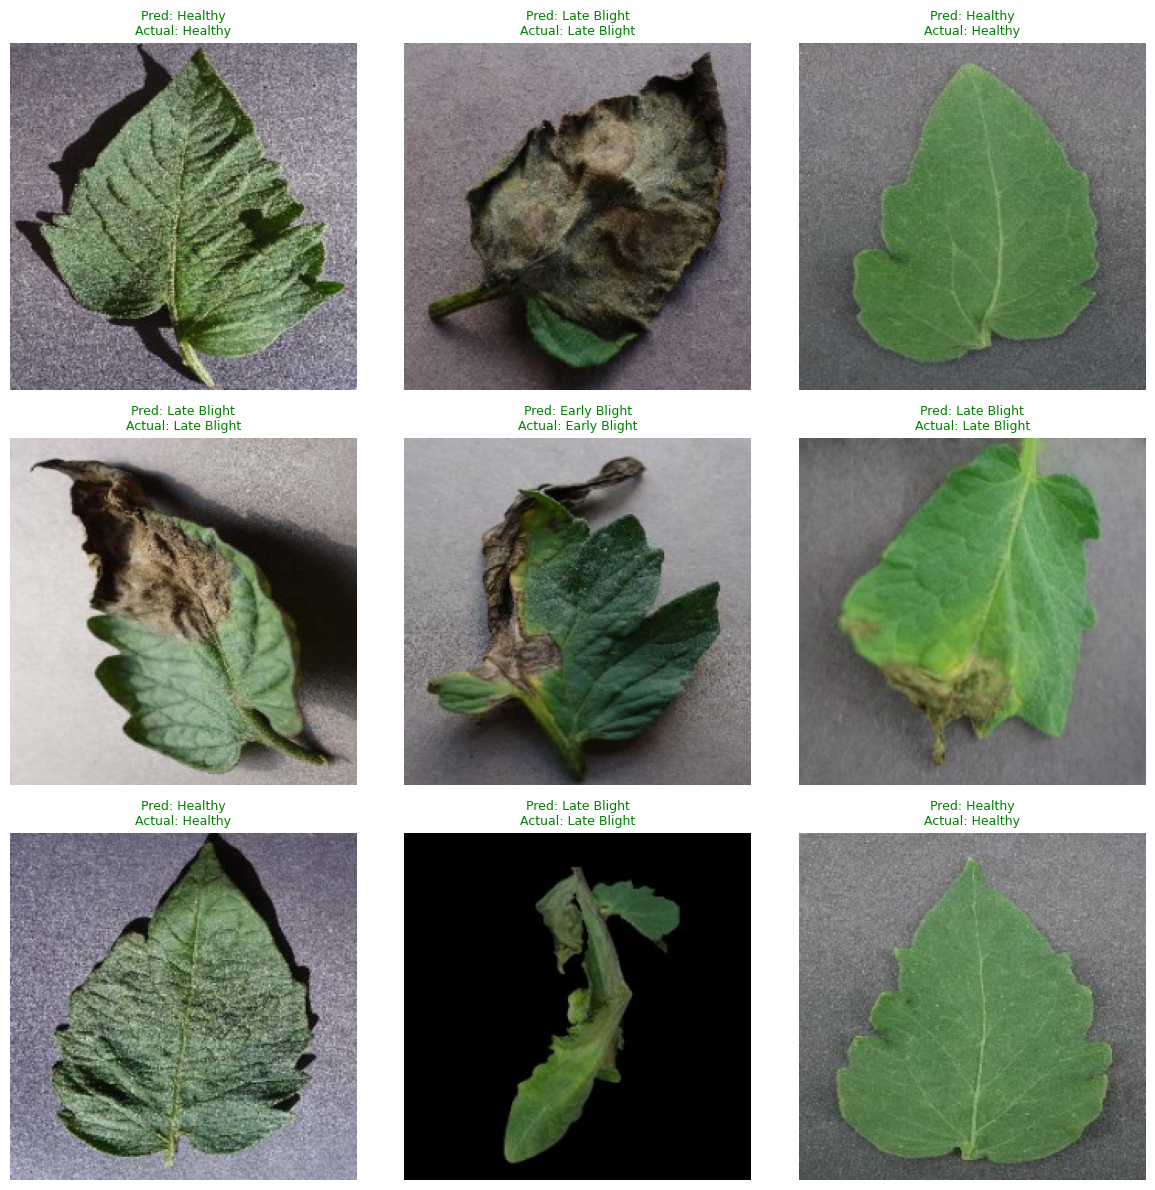

In [43]:
# ==============================
# Sample Predictions
# ==============================

plt.figure(figsize=(12,12))

for images, labels in test_dataset.take(1):

    predictions = transfer_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        predicted = (
           class_names[predicted_labels[i]]
           .replace("Tomato___", "")
           .replace("_", " ")
           .title()
        )

        actual = (
          class_names[labels[i]]
          .replace("Tomato___", "")
          .replace("_", " ")
          .title()
        )

        color = "green" if predicted == actual else "red"

        plt.title(
            f"Pred: {predicted}\nActual: {actual}",
            color=color,
            fontsize=9
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
# ==============================
# Classification Report
# ==============================

print(tl_report)

                       precision    recall  f1-score   support

Tomato___Early_blight       0.94      0.99      0.96       146
 Tomato___Late_blight       1.00      0.97      0.98       274
     Tomato___healthy       1.00      1.00      1.00       255

             accuracy                           0.98       675
            macro avg       0.98      0.99      0.98       675
         weighted avg       0.98      0.98      0.98       675



### 4.1 Metrics Comparison

In [45]:

comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'Training Time (s)',
        'Parameters'
    ]})

comparison_df["Custom CNN"] = [
    f"{custom_cnn_accuracy:.4f}",
    f"{custom_cnn_precision:.4f}",
    f"{custom_cnn_recall:.4f}",
    f"{custom_cnn_f1:.4f}",
    f"{custom_cnn_training_time:.2f}",
    f"{custom_cnn_parameters:,}"
]

comparison_df["Transfer Learning"] = [
    f"{tl_accuracy:.4f}",
    f"{tl_precision:.4f}",
    f"{tl_recall:.4f}",
    f"{tl_f1:.4f}",
    f"{tl_training_time:.2f}",
    f"{total_parameters:,}"
]

In [46]:
print(comparison_df.to_string(index=False))

           Metric Custom CNN Transfer Learning
         Accuracy     0.9452            0.9837
        Precision     0.9376            0.9772
           Recall     0.9356            0.9855
         F1-Score     0.9366            0.9810
Training Time (s)     127.77            153.19
       Parameters    389,187        23,593,859


### 4.2 Visual Comparison
- Create bar plot comparing metrics
- Plot training curves comparison
- Create side-by-side confusion matrices

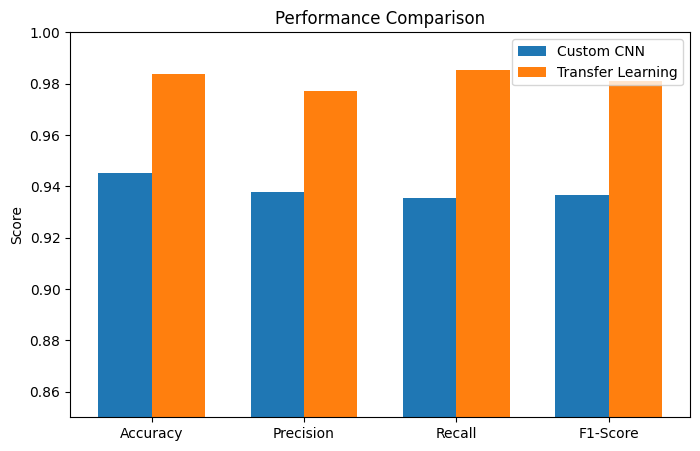

In [47]:
# ==============================
# Performance Metrics Comparison
# ==============================

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

custom_values = [
    custom_cnn_accuracy,
    custom_cnn_precision,
    custom_cnn_recall,
    custom_cnn_f1
]

tl_values = [
    tl_accuracy,
    tl_precision,
    tl_recall,
    tl_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, custom_values, width, label="Custom CNN")
plt.bar(x + width/2, tl_values, width, label="Transfer Learning")

plt.xticks(x, metrics)
plt.ylim(0.85, 1.0)

plt.ylabel("Score")
plt.title("Performance Comparison")
plt.legend()

plt.show()

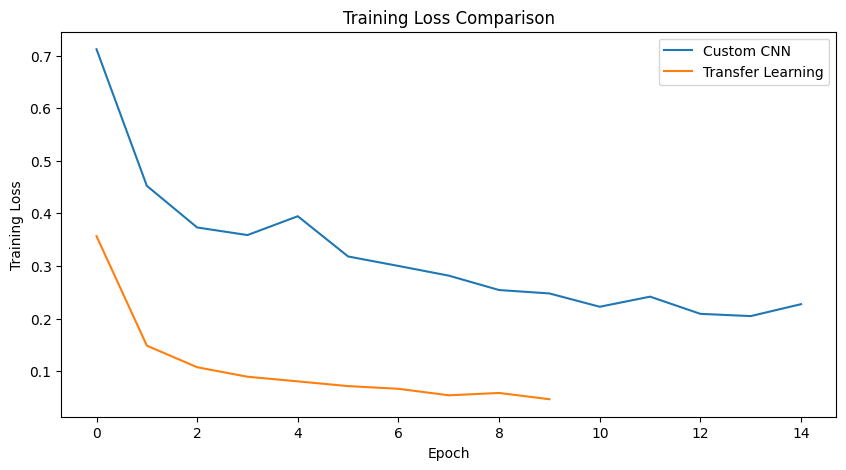

In [48]:
# ==============================
# Training Loss Comparison
# ==============================

plt.figure(figsize=(10,5))

plt.plot(
    custom_history.history["loss"],
    label="Custom CNN"
)

plt.plot(
    tl_history.history["loss"],
    label="Transfer Learning"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.show()

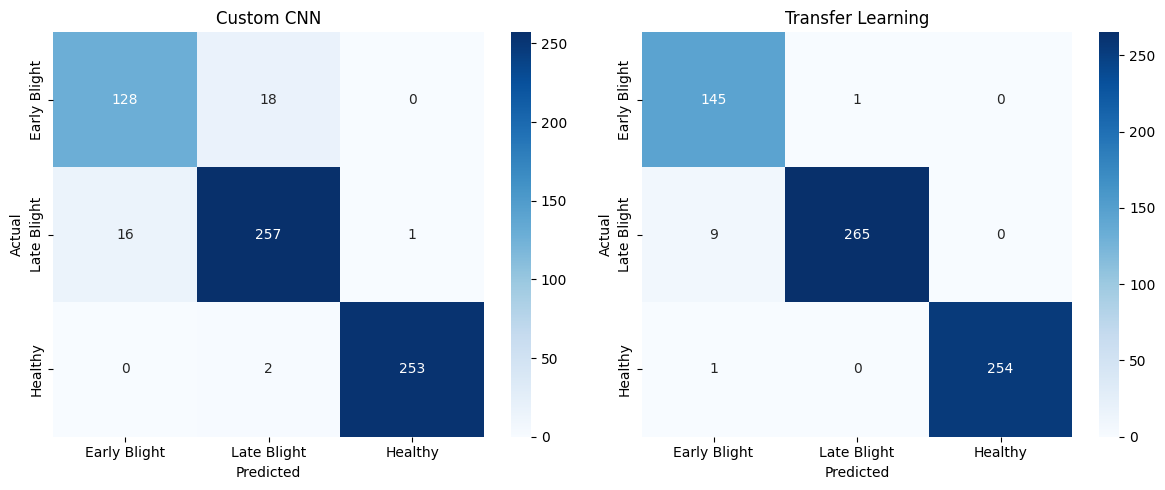

In [49]:
# ==============================
# Side-by-Side Confusion Matrices
# ==============================

display_names = [
    "Early Blight",
    "Late Blight",
    "Healthy"
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    custom_cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_names,
    yticklabels=display_names,
    ax=axes[0]
)

axes[0].set_title("Custom CNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    tl_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_names,
    yticklabels=display_names,
    ax=axes[1]
)

axes[1].set_title("Transfer Learning")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [50]:
analysis_text = f"""
1. Performance Comparison:
The Transfer Learning model outperformed the Custom CNN on all evaluation metrics. The Custom CNN achieved {custom_cnn_accuracy*100:.2f}% accuracy, while the Transfer Learning model achieved {tl_accuracy*100:.2f}%. Precision ({tl_precision*100:.2f}%), Recall ({tl_recall*100:.2f}%), and F1-score ({tl_f1*100:.2f}%) were also higher, demonstrating superior classification performance and better predictive capability.

2. Pre-training vs. Training from Scratch:
The Custom CNN learned image features from scratch, whereas the Transfer Learning model leveraged a pre-trained {pretrained_model_name} backbone. Knowledge learned from ImageNet enabled better feature extraction, improving accuracy and robustness on tomato disease classification.

3. Effect of Global Average Pooling (GAP):
Both models used Global Average Pooling instead of Flatten layers. GAP reduced model complexity, minimized overfitting, lowered trainable parameters in the classification head, and maintained high classification performance.

4. Computational Cost Comparison:
The Custom CNN trained in {custom_cnn_training_time:.2f} seconds with {custom_cnn_parameters:,} parameters, whereas the Transfer Learning model required {tl_training_time:.2f} seconds and contained {total_parameters:,} parameters. Despite higher computational cost, it produced significantly better predictions.

5. Transfer Learning Insights:
Transfer Learning achieved a lower final loss ({tl_final_loss:.4f} vs. {custom_cnn_final_loss:.4f}), fewer misclassifications, and better generalization on unseen tomato leaf images.

6. Convergence Behaviour:
Both models converged successfully. However, the Transfer Learning model reduced training loss from {tl_initial_loss:.4f} to {tl_final_loss:.4f}, while the Custom CNN reduced loss from {custom_cnn_initial_loss:.4f} to {custom_cnn_final_loss:.4f}, confirming the effectiveness of pre-trained feature representations and stable optimization.
"""

In [51]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

1. Performance Comparison:
The Transfer Learning model outperformed the Custom CNN on all evaluation metrics. The Custom CNN achieved 94.52% accuracy, while the Transfer Learning model achieved 98.37%. Precision (97.72%), Recall (98.55%), and F1-score (98.10%) were also higher, demonstrating superior classification performance and better predictive capability.

2. Pre-training vs. Training from Scratch:
The Custom CNN learned image features from scratch, whereas the Transfer Learning model leveraged a pre-trained ResNet50 backbone. Knowledge learned from ImageNet enabled better feature extraction, improving accuracy and robustness on tomato disease classification.

3. Effect of Global Average Pooling (GAP):
Both models used Global Average Pooling instead of Flatten layers. GAP reduced model complexity, minimized overfitting, lowered trainable parameters in the classification head, and maintained high classification performance.

4. Computational Cost Comparison:
The Custom CN

In [52]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 4,
                'pooling_layers': 3,
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': custom_cnn_parameters
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 15,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

In [53]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "PlantVillage (Tomato Disease Classification)",
  "dataset_source": "https://github.com/spMohanty/PlantVillage-Dataset",
  "n_samples": 4500,
  "n_classes": 3,
  "samples_per_class": "min: 1000, max: 1909, avg: 1500",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "\nAccuracy is selected as the primary evaluation metric because the PlantVillage\ndataset contains reasonably balanced classes and the objective is overall\ncorrect classification of plant leaf diseases. Precision, Recall, and F1-score\nwill also be reported to provide a comprehensive evaluation of model performance.\n",
  "train_samples": 3825,
  "test_samples": 675,
  "train_test_ratio": "85/15",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 4,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax"

In [54]:
# Display system information
import platform
import sys
from datetime import datetime

In [55]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here



ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


### Environment Verification

**Google Colab environment showing notebook name, account details, and runtime information.**

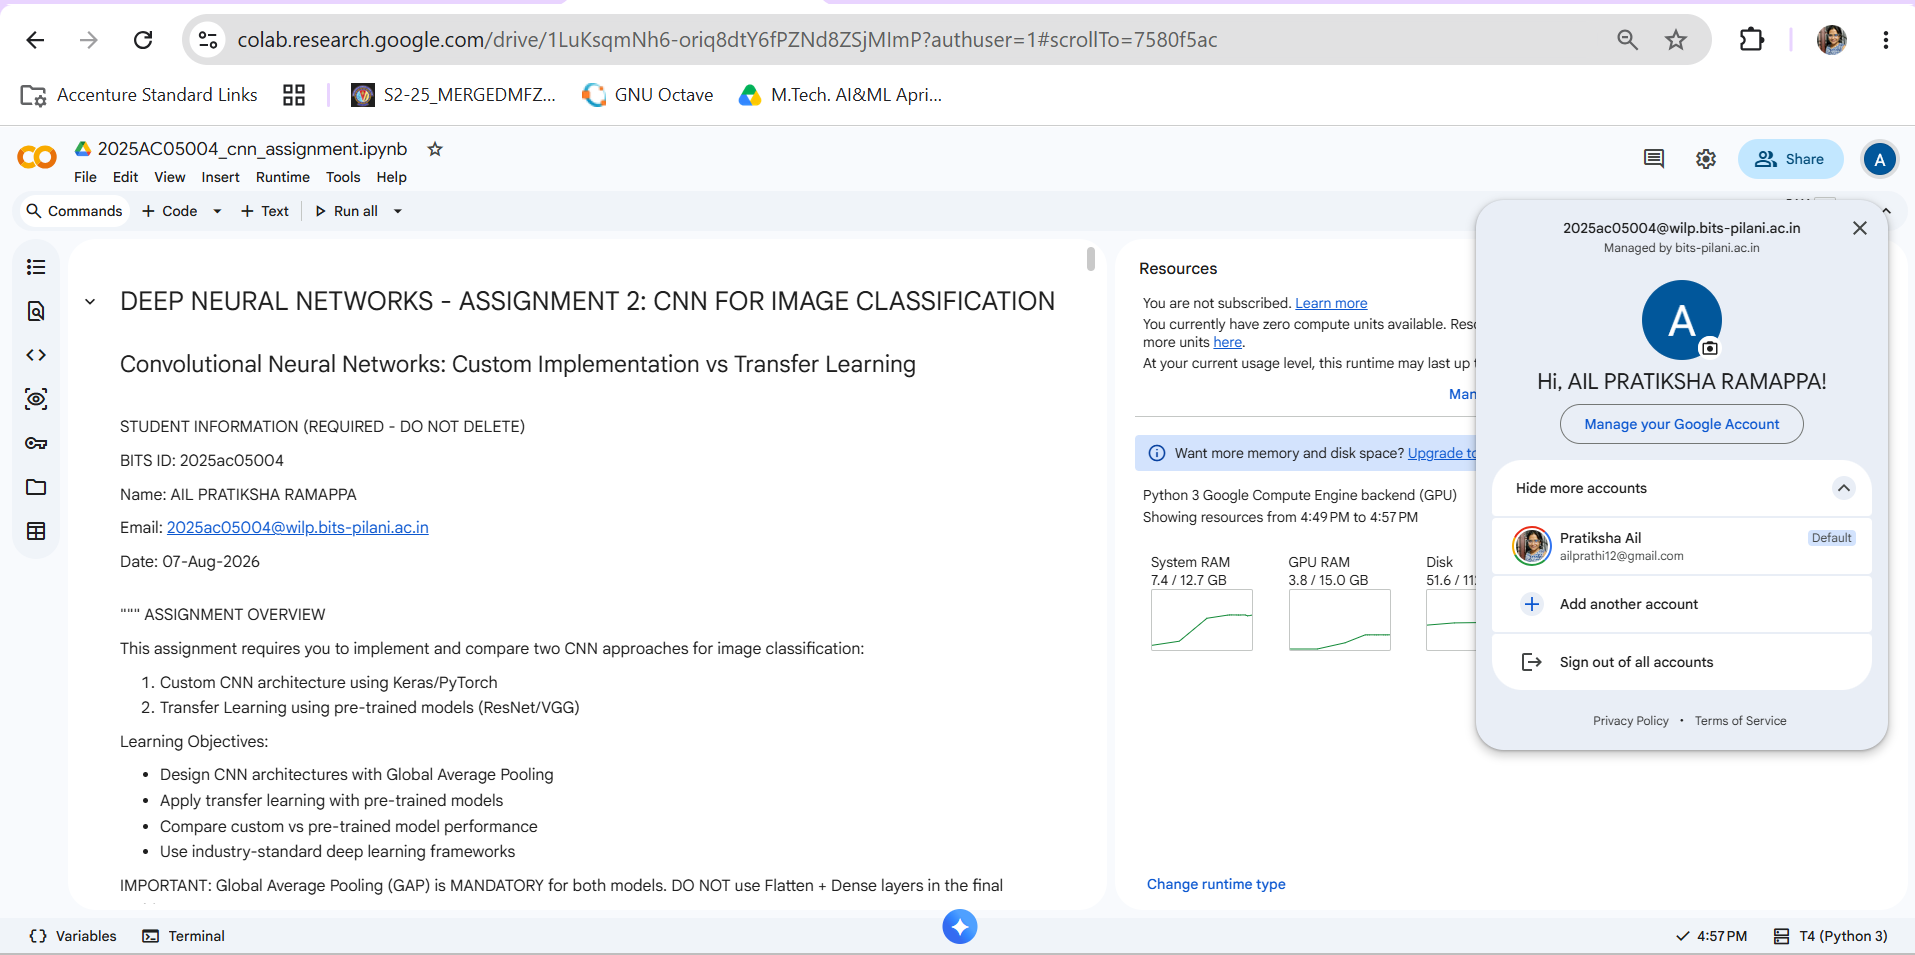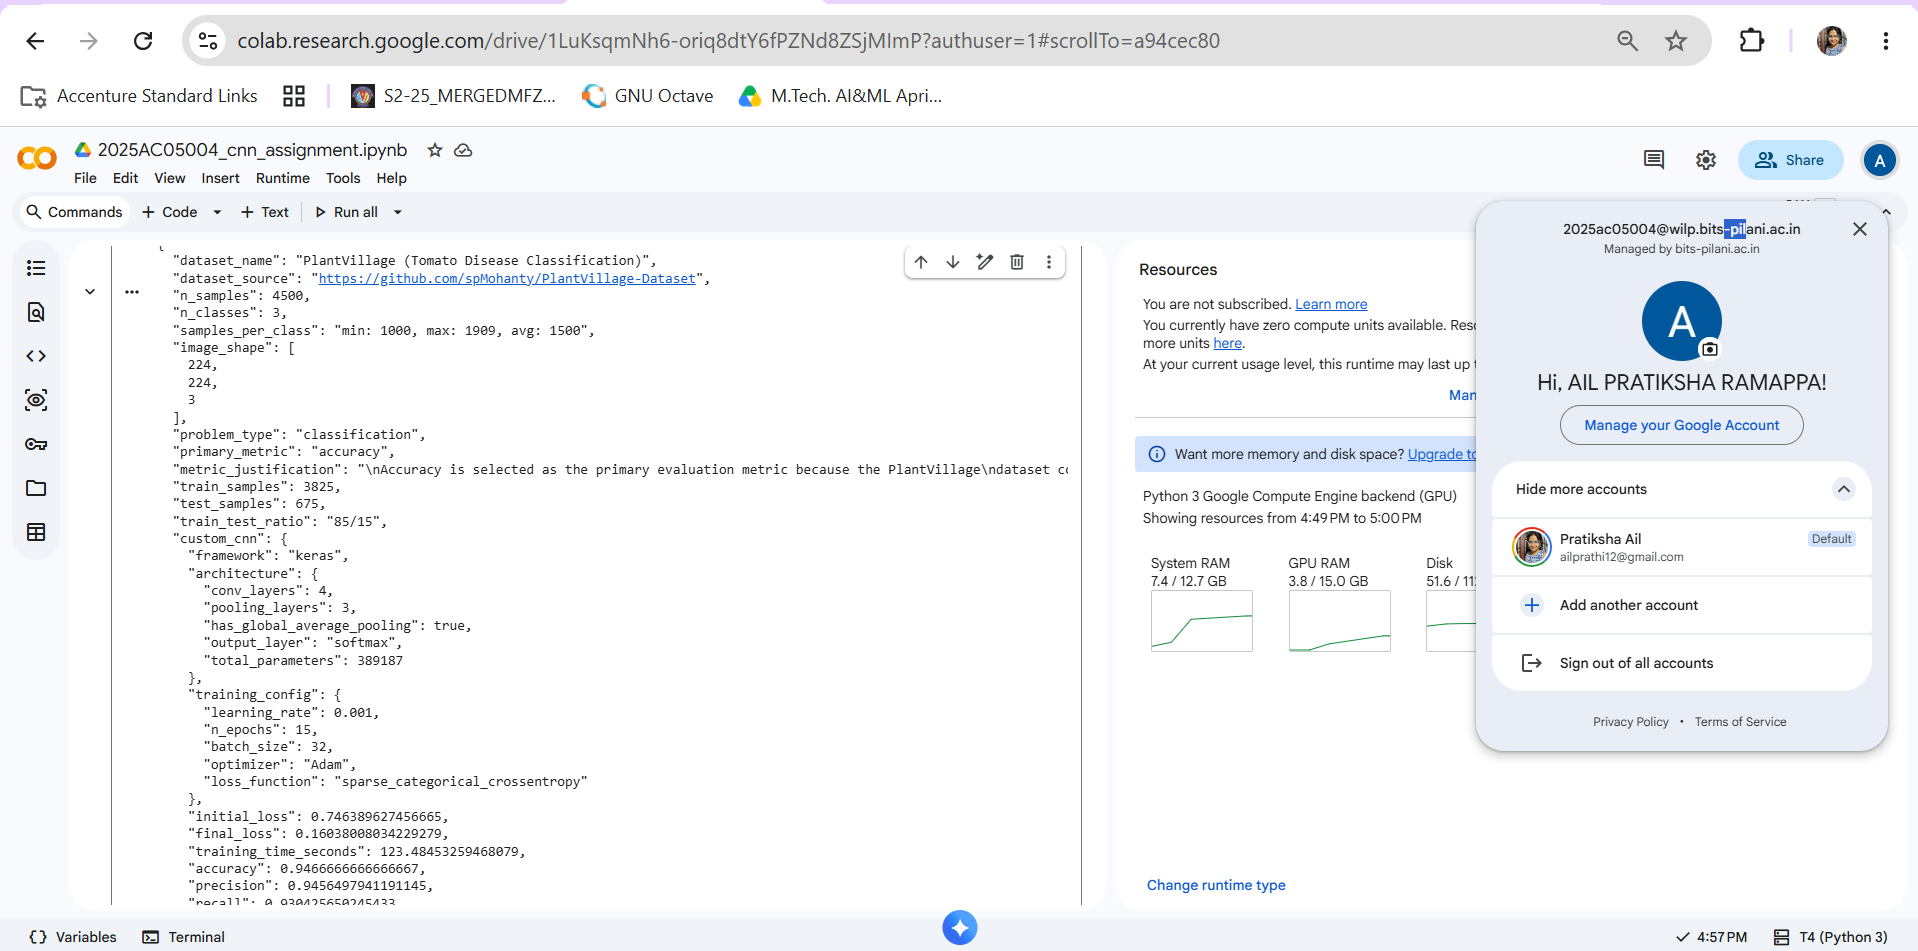


